# RSNA Knee MRI — Clean SSL Training Pipeline

Self-supervised learning pipeline using validated preprocessing outputs.

## Validated preprocessing state

- Unlabelled studies: 4,349
- MRI series: 24,035
- Indexed slices: 808,550
- Original 2.5D triplets: 760,480
- Train studies: 3,914
- Validation studies: 435
- Train series: 21,640
- Validation series: 2,395
- Corrupted DICOM slices identified: 2
- Final clean triplets: 760,478
- Balanced training samples per epoch: 86,560
- Fixed validation samples: 9,580

In [4]:
# ============================================================
# STEP 1
# Imports and configuration
# ============================================================

from pathlib import Path
import random

import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F
import pydicom


SEED = 42
TARGET_SIZE = 224
TRIPLETS_PER_SERIES = 4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.10.0+cpu
CUDA available: False


In [5]:
# ============================================================
# STEP 2
# Input paths
# ============================================================

COMPETITION_ROOT = Path(
    "/kaggle/input/competitions/"
    "rsna-knee-abnormality-detection"
)

PREP_ROOT = Path(
    "/kaggle/input/notebooks/elliotyang37/"
    "final-version/rsna_ssl_clean"
)


print("Competition input exists:", COMPETITION_ROOT.exists())
print("Saved preprocessing input exists:", PREP_ROOT.exists())

Competition input exists: True
Saved preprocessing input exists: True


In [6]:
# ============================================================
# STEP 3
# Load validated preprocessing checkpoints
# ============================================================

ssl_series_df = pd.read_csv(
    PREP_ROOT
    / "indexes/step02_ssl_series_inventory.csv"
)

ssl_slice_index = pd.read_parquet(
    PREP_ROOT
    / "indexes/step03_ssl_slice_index.parquet"
)

ssl_triplets = pd.read_parquet(
    PREP_ROOT
    / "indexes/step04_ssl_triplets.parquet"
)

study_split_df = pd.read_csv(
    PREP_ROOT
    / "splits/step05_study_split.csv"
)

series_split_df = pd.read_csv(
    PREP_ROOT
    / "splits/step05_series_split.csv"
)

ssl_triplets_split = pd.read_parquet(
    PREP_ROOT
    / "splits/step05_triplets_with_split.parquet"
)

series_percentiles = pd.read_parquet(
    PREP_ROOT
    / "indexes/step06_series_percentiles.parquet"
)

In [4]:
print("Studies:", ssl_series_df["StudyInstanceUID"].nunique())
print("Series:", len(ssl_series_df))
print("Slices:", len(ssl_slice_index))
print("Triplets:", len(ssl_triplets))

print("\nStudy split:")
print(study_split_df["SSL_Split"].value_counts())

print("\nSeries split:")
print(series_split_df["SSL_Split"].value_counts())

print("\nPercentile cache:")
print(series_percentiles["Valid"].value_counts())

Studies: 4349
Series: 24035
Slices: 808550
Triplets: 760480

Study split:
SSL_Split
train    3914
val       435
Name: count, dtype: int64

Series split:
SSL_Split
train    21640
val       2395
Name: count, dtype: int64

Percentile cache:
Valid
True     24033
False        2
Name: count, dtype: int64


In [7]:
# ============================================================
# STEP 4
# Repair percentile statistics for corrupted-DICOM series
# ============================================================

def load_dicom_pixels(path):

    ds = pydicom.dcmread(
        str(path),
        force=True
    )

    image = ds.pixel_array.astype(np.float32)

    slope = float(
        getattr(ds, "RescaleSlope", 1.0)
    )

    intercept = float(
        getattr(ds, "RescaleIntercept", 0.0)
    )

    image = image * slope + intercept

    if getattr(
        ds,
        "PhotometricInterpretation",
        ""
    ) == "MONOCHROME1":

        image = (
            image.max()
            + image.min()
            - image
        )

    return image


invalid_series = (
    series_percentiles.loc[
        ~series_percentiles["Valid"],
        "SeriesInstanceUID"
    ]
    .tolist()
)

print("Series requiring repair:", len(invalid_series))


bad_slice_rows = []


for series_uid in invalid_series:

    series_rows = (
        ssl_slice_index[
            ssl_slice_index["SeriesInstanceUID"]
            == series_uid
        ]
        .sort_values("SlicePosition")
    )

    good_pixels = []

    for row in series_rows.itertuples(index=False):

        try:

            image = load_dicom_pixels(
                row.SlicePath
            )

            good_pixels.append(
                image.reshape(-1)
            )

        except Exception as e:

            bad_slice_rows.append(
                {
                    "SeriesInstanceUID": series_uid,
                    "SlicePath": row.SlicePath,
                    "Error": str(e),
                }
            )


    pixels = np.concatenate(
        good_pixels
    )

    p1 = float(
        np.percentile(pixels, 1)
    )

    p99 = float(
        np.percentile(pixels, 99)
    )

    mask = (
        series_percentiles["SeriesInstanceUID"]
        == series_uid
    )

    series_percentiles.loc[
        mask,
        "P1"
    ] = p1

    series_percentiles.loc[
        mask,
        "P99"
    ] = p99

    series_percentiles.loc[
        mask,
        "Valid"
    ] = p99 > p1


bad_slices_df = pd.DataFrame(
    bad_slice_rows
)


print()
print("Corrupted DICOM slices:", len(bad_slices_df))

print()
print("Percentile cache:")
print(
    series_percentiles["Valid"]
    .value_counts()
)

Series requiring repair: 2

Corrupted DICOM slices: 2

Percentile cache:
Valid
True    24035
Name: count, dtype: int64


In [6]:
# ============================================================
# STEP 5
# Remove triplets that touch corrupted DICOM slices
# ============================================================

bad_paths = set(
    bad_slices_df["SlicePath"]
    .astype(str)
)


bad_triplet_mask = (

    ssl_triplets_split["PreviousPath"]
    .astype(str)
    .isin(bad_paths)

    |

    ssl_triplets_split["CentrePath"]
    .astype(str)
    .isin(bad_paths)

    |

    ssl_triplets_split["NextPath"]
    .astype(str)
    .isin(bad_paths)
)


ssl_triplets_clean = (
    ssl_triplets_split[
        ~bad_triplet_mask
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    "Triplets removed:",
    int(bad_triplet_mask.sum())
)

print(
    "Final clean triplets:",
    f"{len(ssl_triplets_clean):,}"
)

print()

print("Series by split:")
print(
    ssl_triplets_clean
    .groupby("SSL_Split")[
        "SeriesInstanceUID"
    ]
    .nunique()
)

Triplets removed: 2
Final clean triplets: 760,478

Series by split:
SSL_Split
train    21640
val       2395
Name: SeriesInstanceUID, dtype: int64


In [7]:
# ============================================================
# STEP 6
# Final preprocessing validation
# ============================================================

triplets_per_series = (
    ssl_triplets_clean
    .groupby("SeriesInstanceUID")
    .size()
)


assert len(ssl_triplets_clean) == 760478

assert (
    series_percentiles["Valid"]
    .all()
)

assert len(series_percentiles) == 24035

assert len(bad_slices_df) == 2

assert (
    ssl_triplets_clean[
        "StudyInstanceUID"
    ].nunique()
    == 4349
)

assert (
    ssl_triplets_clean[
        "SeriesInstanceUID"
    ].nunique()
    == 24035
)

assert (
    triplets_per_series >= 4
).all()


print("✓ Clean triplets:", f"{len(ssl_triplets_clean):,}")
print("✓ Valid percentile series:", len(series_percentiles))
print("✓ Corrupted DICOM slices excluded:", len(bad_slices_df))
print("✓ Studies retained:", ssl_triplets_clean["StudyInstanceUID"].nunique())
print("✓ Series retained:", ssl_triplets_clean["SeriesInstanceUID"].nunique())
print("✓ Minimum clean triplets / series:", triplets_per_series.min())

print()
print("CLEAN PREPROCESSING STATE VALIDATED")

✓ Clean triplets: 760,478
✓ Valid percentile series: 24035
✓ Corrupted DICOM slices excluded: 2
✓ Studies retained: 4349
✓ Series retained: 24035
✓ Minimum clean triplets / series: 9

CLEAN PREPROCESSING STATE VALIDATED


In [8]:
# ============================================================
# STEP 7
# Save final SSL preprocessing artifacts
# ============================================================

FINAL_DIR = Path(
    "/kaggle/working/ssl_prepared"
)

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


ssl_triplets_clean.to_parquet(
    FINAL_DIR / "ssl_clean_triplets.parquet",
    index=False
)

series_percentiles.to_parquet(
    FINAL_DIR / "series_percentiles.parquet",
    index=False
)

bad_slices_df.to_csv(
    FINAL_DIR / "corrupted_slices.csv",
    index=False
)

study_split_df.to_csv(
    FINAL_DIR / "study_split.csv",
    index=False
)

series_split_df.to_csv(
    FINAL_DIR / "series_split.csv",
    index=False
)


print("Saved final preprocessing files:\n")

for file in sorted(FINAL_DIR.iterdir()):
    print("✓", file.name)

Saved final preprocessing files:

✓ corrupted_slices.csv
✓ series_percentiles.parquet
✓ series_split.csv
✓ ssl_clean_triplets.parquet
✓ study_split.csv


In [9]:
# ============================================================
# STEP 7A
# MRI preprocessing functions
# ============================================================

def load_dicom_for_training(path):

    ds = pydicom.dcmread(
        str(path),
        force=True
    )

    image = ds.pixel_array.astype(np.float32)

    slope = float(
        getattr(ds, "RescaleSlope", 1.0)
    )

    intercept = float(
        getattr(ds, "RescaleIntercept", 0.0)
    )

    image = image * slope + intercept

    if getattr(
        ds,
        "PhotometricInterpretation",
        ""
    ) == "MONOCHROME1":

        image = (
            image.max()
            + image.min()
            - image
        )

    spacing_y = float(ds.PixelSpacing[0])
    spacing_x = float(ds.PixelSpacing[1])

    return image, spacing_y, spacing_x


def normalize_mri(image, p1, p99):

    image = np.clip(
        image,
        p1,
        p99
    )

    if p99 <= p1:
        return np.zeros_like(
            image,
            dtype=np.float32
        )

    image = (
        image - p1
    ) / (p99 - p1)

    return image.astype(np.float32)


def physical_fov_resize(
    image,
    spacing_y,
    spacing_x,
    target_size=224
):

    h, w = image.shape

    physical_h = h * spacing_y
    physical_w = w * spacing_x

    scale = min(
        target_size / physical_h,
        target_size / physical_w
    )

    new_h = max(
        1,
        min(
            target_size,
            round(physical_h * scale)
        )
    )

    new_w = max(
        1,
        min(
            target_size,
            round(physical_w * scale)
        )
    )

    x = torch.from_numpy(
        image
    ).float()[None, None]

    x = F.interpolate(
        x,
        size=(new_h, new_w),
        mode="bilinear",
        align_corners=False
    )

    return x[0, 0]


def centre_pad(image, target_size=224):

    h, w = image.shape

    pad_h = target_size - h
    pad_w = target_size - w

    top = pad_h // 2
    bottom = pad_h - top

    left = pad_w // 2
    right = pad_w - left

    return F.pad(
        image,
        (left, right, top, bottom),
        value=0.0
    )


def preprocess_mri_slice(
    path,
    p1,
    p99
):

    image, sy, sx = (
        load_dicom_for_training(path)
    )

    image = normalize_mri(
        image,
        p1,
        p99
    )

    image = physical_fov_resize(
        image,
        sy,
        sx
    )

    image = centre_pad(
        image
    )

    return image


def preprocess_25d_triplet(
    row,
    p1,
    p99
):

    previous = preprocess_mri_slice(
        row["PreviousPath"],
        p1,
        p99
    )

    centre = preprocess_mri_slice(
        row["CentrePath"],
        p1,
        p99
    )

    next_slice = preprocess_mri_slice(
        row["NextPath"],
        p1,
        p99
    )

    return torch.stack(
        [
            previous,
            centre,
            next_slice
        ],
        dim=0
    )


print("✓ MRI preprocessing functions ready")

✓ MRI preprocessing functions ready


In [10]:
percentile_lookup = (
    series_percentiles
    .set_index("SeriesInstanceUID")[
        ["P1", "P99"]
    ]
    .to_dict("index")
)

print(
    "Percentile lookup entries:",
    len(percentile_lookup)
)

Percentile lookup entries: 24035


In [11]:
# ============================================================
# STEP 7B
# MRI-safe SSL augmentation
# ============================================================

import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


def mri_ssl_augment(x):
    """
    Apply conservative MRI-safe augmentation.

    Input:
        x: Tensor [3, 224, 224], range [0, 1]

    The same spatial transform is applied to all 3 channels,
    preserving previous/centre/next slice alignment.
    """

    x = x.clone()

    # --------------------------------------------------------
    # Mild spatial augmentation
    # --------------------------------------------------------
    if random.random() < 0.8:

        angle = random.uniform(-8.0, 8.0)

        tx = int(
            round(
                random.uniform(-0.04, 0.04)
                * x.shape[-1]
            )
        )

        ty = int(
            round(
                random.uniform(-0.04, 0.04)
                * x.shape[-2]
            )
        )

        scale = random.uniform(
            0.95,
            1.05
        )

        x = TF.affine(
            x,
            angle=angle,
            translate=[tx, ty],
            scale=scale,
            shear=[0.0, 0.0],
            interpolation=InterpolationMode.BILINEAR,
            fill=0.0
        )


    # --------------------------------------------------------
    # Mild intensity scaling
    # --------------------------------------------------------
    if random.random() < 0.8:

        factor = random.uniform(
            0.90,
            1.10
        )

        x = x * factor


    # --------------------------------------------------------
    # Mild intensity shift
    # --------------------------------------------------------
    if random.random() < 0.5:

        shift = random.uniform(
            -0.05,
            0.05
        )

        x = x + shift


    # --------------------------------------------------------
    # Mild gamma adjustment
    # --------------------------------------------------------
    if random.random() < 0.5:

        gamma = random.uniform(
            0.90,
            1.10
        )

        x = torch.clamp(
            x,
            0.0,
            1.0
        )

        x = x.pow(gamma)


    # --------------------------------------------------------
    # Mild Gaussian noise
    # --------------------------------------------------------
    if random.random() < 0.5:

        sigma = random.uniform(
            0.0,
            0.025
        )

        x = (
            x
            + torch.randn_like(x) * sigma
        )


    return torch.clamp(
        x,
        0.0,
        1.0
    )


def make_ssl_views(x):

    view1 = mri_ssl_augment(x)
    view2 = mri_ssl_augment(x)

    return view1, view2


print("✓ MRI-safe two-view augmentation ready")

✓ MRI-safe two-view augmentation ready


In [12]:
# ============================================================
# STEP 7C
# Augmentation QC
# ============================================================

test_row = ssl_triplets_clean.iloc[0]

series_uid = test_row["SeriesInstanceUID"]

stats = percentile_lookup[series_uid]

p1 = float(stats["P1"])
p99 = float(stats["P99"])


base_sample = preprocess_25d_triplet(
    test_row,
    p1,
    p99
)


view1, view2 = make_ssl_views(
    base_sample
)


print("Base shape:", base_sample.shape)

print("View 1 shape:", view1.shape)
print("View 2 shape:", view2.shape)

print()

print(
    "View 1 range:",
    float(view1.min()),
    float(view1.max())
)

print(
    "View 2 range:",
    float(view2.min()),
    float(view2.max())
)

print()

mean_difference = (
    torch.abs(
        view1 - view2
    )
    .mean()
    .item()
)

print(
    "Mean absolute difference:",
    mean_difference
)

print(
    "Plane:",
    test_row["Anatomical_Plane"]
)

assert base_sample.shape == (3, 224, 224)
assert view1.shape == (3, 224, 224)
assert view2.shape == (3, 224, 224)

assert torch.isfinite(view1).all()
assert torch.isfinite(view2).all()

assert view1.min() >= 0
assert view1.max() <= 1

assert view2.min() >= 0
assert view2.max() <= 1

assert mean_difference > 0

print()
print("✓ Two-view augmentation QC passed")

Base shape: torch.Size([3, 224, 224])
View 1 shape: torch.Size([3, 224, 224])
View 2 shape: torch.Size([3, 224, 224])

View 1 range: 0.0 1.0
View 2 range: 0.014109227806329727 1.0

Mean absolute difference: 0.09526766836643219
Plane: Sagittal

✓ Two-view augmentation QC passed


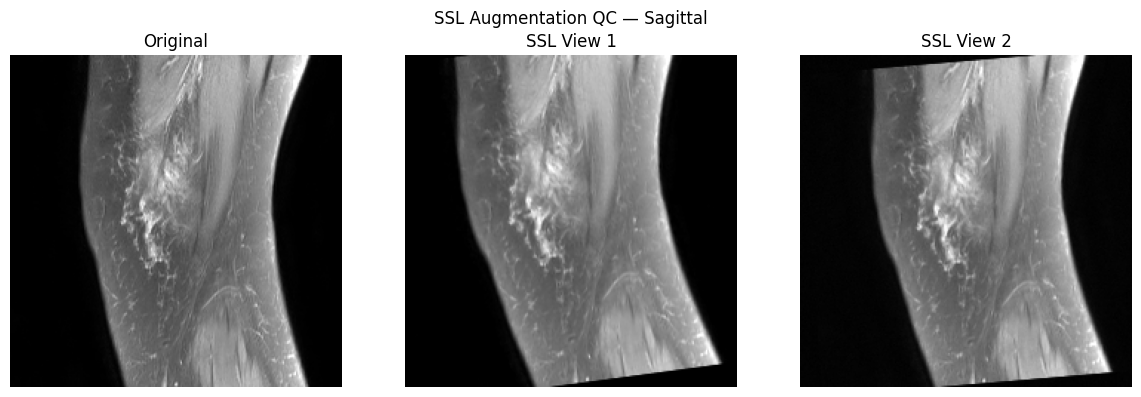

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4)
)

axes[0].imshow(
    base_sample[1].cpu().numpy(),
    cmap="gray"
)
axes[0].set_title("Original")

axes[1].imshow(
    view1[1].cpu().numpy(),
    cmap="gray"
)
axes[1].set_title("SSL View 1")

axes[2].imshow(
    view2[1].cpu().numpy(),
    cmap="gray"
)
axes[2].set_title("SSL View 2")

for ax in axes:
    ax.axis("off")

plt.suptitle(
    f"SSL Augmentation QC — "
    f"{test_row['Anatomical_Plane']}"
)

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# STEP 8A
# Train / validation clean triplet pools
# ============================================================

train_triplets = (
    ssl_triplets_clean[
        ssl_triplets_clean["SSL_Split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

val_triplets = (
    ssl_triplets_clean[
        ssl_triplets_clean["SSL_Split"] == "val"
    ]
    .copy()
    .reset_index(drop=True)
)


print("Train triplets:", f"{len(train_triplets):,}")
print("Validation triplets:", f"{len(val_triplets):,}")

print()

print(
    "Train series:",
    train_triplets["SeriesInstanceUID"].nunique()
)

print(
    "Validation series:",
    val_triplets["SeriesInstanceUID"].nunique()
)

Train triplets: 685,629
Validation triplets: 74,849

Train series: 21640
Validation series: 2395


In [15]:
# ============================================================
# STEP 8B
# Sample exactly 4 triplets per MRI series
# ============================================================

def sample_balanced_triplets(
    triplet_df,
    n_per_series=4,
    seed=42
):

    rng = np.random.default_rng(seed)

    sampled_parts = []

    for _, group in triplet_df.groupby(
        "SeriesInstanceUID",
        sort=False
    ):

        indices = group.index.to_numpy()

        chosen = rng.choice(
            indices,
            size=n_per_series,
            replace=False
        )

        sampled_parts.append(
            triplet_df.loc[chosen]
        )


    sampled_df = (
        pd.concat(
            sampled_parts,
            ignore_index=True
        )
        .sample(
            frac=1,
            random_state=seed
        )
        .reset_index(drop=True)
    )

    return sampled_df

In [16]:
# ============================================================
# STEP 8C
# Fixed validation manifest
# ============================================================

VAL_SAMPLE_SEED = 2026

val_manifest = sample_balanced_triplets(
    val_triplets,
    n_per_series=TRIPLETS_PER_SERIES,
    seed=VAL_SAMPLE_SEED
)


print(
    "Validation samples:",
    f"{len(val_manifest):,}"
)

print(
    "Validation series:",
    val_manifest["SeriesInstanceUID"].nunique()
)

print()

val_counts = (
    val_manifest
    .groupby("SeriesInstanceUID")
    .size()
)

print(
    "Samples per validation series:"
)

print(
    val_counts.value_counts()
)

Validation samples: 9,580
Validation series: 2395

Samples per validation series:
4    2395
Name: count, dtype: int64


In [17]:
# ============================================================
# STEP 8D
# Example training manifest for epoch 1
# ============================================================

train_manifest_epoch1 = sample_balanced_triplets(
    train_triplets,
    n_per_series=TRIPLETS_PER_SERIES,
    seed=SEED + 1
)


print(
    "Training samples:",
    f"{len(train_manifest_epoch1):,}"
)

print(
    "Training series:",
    train_manifest_epoch1[
        "SeriesInstanceUID"
    ].nunique()
)

print()

train_counts = (
    train_manifest_epoch1
    .groupby("SeriesInstanceUID")
    .size()
)

print(
    "Samples per training series:"
)

print(
    train_counts.value_counts()
)

Training samples: 86,560
Training series: 21640

Samples per training series:
4    21640
Name: count, dtype: int64


In [18]:
assert len(train_manifest_epoch1) == 86560
assert len(val_manifest) == 9580

assert (
    train_manifest_epoch1[
        "SeriesInstanceUID"
    ].nunique()
    == 21640
)

assert (
    val_manifest[
        "SeriesInstanceUID"
    ].nunique()
    == 2395
)

assert (
    train_counts == 4
).all()

assert (
    val_counts == 4
).all()

print("✓ Train manifest: 86,560")
print("✓ Validation manifest: 9,580")
print("✓ Exactly 4 samples per series")
print()
print("CLEAN STEP 8 PASSED")

✓ Train manifest: 86,560
✓ Validation manifest: 9,580
✓ Exactly 4 samples per series

CLEAN STEP 8 PASSED


In [19]:
# ============================================================
# STEP 9A
# PyTorch Dataset for 2-view SSL
# ============================================================

from torch.utils.data import Dataset, DataLoader


class KneeSSLDataset(Dataset):

    def __init__(
        self,
        manifest,
        percentile_lookup,
        augment=True
    ):

        self.manifest = (
            manifest
            .reset_index(drop=True)
            .copy()
        )

        self.percentile_lookup = percentile_lookup
        self.augment = augment


    def __len__(self):

        return len(self.manifest)


    def __getitem__(self, idx):

        row = self.manifest.iloc[idx]

        series_uid = row["SeriesInstanceUID"]

        stats = self.percentile_lookup[
            series_uid
        ]

        p1 = float(stats["P1"])
        p99 = float(stats["P99"])


        # --------------------------------------------
        # Load + preprocess original 2.5D triplet
        # --------------------------------------------

        sample = preprocess_25d_triplet(
            row,
            p1,
            p99
        )


        # --------------------------------------------
        # Two SSL views
        # --------------------------------------------

        if self.augment:

            view1, view2 = make_ssl_views(
                sample
            )

        else:

            view1 = sample.clone()
            view2 = sample.clone()


        return {
            "view1": view1,
            "view2": view2,
            "series_uid": series_uid,
            "study_uid": row["StudyInstanceUID"],
            "plane": row["Anatomical_Plane"],
        }


print("✓ KneeSSLDataset ready")

✓ KneeSSLDataset ready


In [20]:
# ============================================================
# STEP 9B
# Build train / validation datasets
# ============================================================

train_dataset = KneeSSLDataset(
    manifest=train_manifest_epoch1,
    percentile_lookup=percentile_lookup,
    augment=True
)

val_dataset = KneeSSLDataset(
    manifest=val_manifest,
    percentile_lookup=percentile_lookup,
    augment=True
)


print(
    "Train dataset:",
    f"{len(train_dataset):,}"
)

print(
    "Validation dataset:",
    f"{len(val_dataset):,}"
)

Train dataset: 86,560
Validation dataset: 9,580


In [21]:
# ============================================================
# STEP 9C
# Single-sample Dataset QC
# ============================================================

sample = train_dataset[0]


print(
    "View 1:",
    sample["view1"].shape
)

print(
    "View 2:",
    sample["view2"].shape
)

print(
    "View 1 range:",
    float(sample["view1"].min()),
    float(sample["view1"].max())
)

print(
    "View 2 range:",
    float(sample["view2"].min()),
    float(sample["view2"].max())
)

print(
    "Plane:",
    sample["plane"]
)

print(
    "Series:",
    sample["series_uid"]
)

View 1: torch.Size([3, 224, 224])
View 2: torch.Size([3, 224, 224])
View 1 range: 0.034749437123537064 0.9532986283302307
View 2 range: 0.0 1.0
Plane: Sagittal
Series: 1.2.826.0.1.3680043.8.498.47787342240473738685118996530213255819


In [22]:
assert sample["view1"].shape == (3, 224, 224)
assert sample["view2"].shape == (3, 224, 224)

assert torch.isfinite(
    sample["view1"]
).all()

assert torch.isfinite(
    sample["view2"]
).all()

print()
print("✓ Single Dataset sample passed")


✓ Single Dataset sample passed


In [23]:
# ============================================================
# STEP 9D
# DataLoaders
# ============================================================

BATCH_SIZE = 16
NUM_WORKERS = 2


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=False
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Train batches: 5410
Validation batches: 599


In [24]:
# ============================================================
# STEP 9E
# DataLoader batch QC
# ============================================================

batch = next(
    iter(train_loader)
)


view1 = batch["view1"]
view2 = batch["view2"]


print(
    "View 1 batch:",
    view1.shape
)

print(
    "View 2 batch:",
    view2.shape
)

print()

print(
    "View 1 range:",
    float(view1.min()),
    float(view1.max())
)

print(
    "View 2 range:",
    float(view2.min()),
    float(view2.max())
)

print()

print(
    "Studies in batch:",
    len(batch["study_uid"])
)

print(
    "Planes:",
    batch["plane"][:5]
)

View 1 batch: torch.Size([16, 3, 224, 224])
View 2 batch: torch.Size([16, 3, 224, 224])

View 1 range: 0.0 1.0
View 2 range: 0.0 1.0

Studies in batch: 16
Planes: ['Coronal', 'Sagittal', 'Axial', 'Coronal', 'Coronal']


In [25]:
assert view1.shape == (
    BATCH_SIZE,
    3,
    224,
    224
)

assert view2.shape == (
    BATCH_SIZE,
    3,
    224,
    224
)

assert torch.isfinite(
    view1
).all()

assert torch.isfinite(
    view2
).all()

print()
print("✓ Dataset works")
print("✓ DataLoader works")
print("✓ Two-view batches work")
print()
print("CLEAN STEP 9 PASSED")


✓ Dataset works
✓ DataLoader works
✓ Two-view batches work

CLEAN STEP 9 PASSED


In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [28]:
# ============================================================
# GPU DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [2]:
# ============================================================
# STEP 10B
# SimCLR ResNet-18 encoder
# ============================================================

import torch.nn as nn
from torchvision.models import resnet18


class SimCLRModel(nn.Module):

    def __init__(
        self,
        projection_dim=128
    ):

        super().__init__()

        # --------------------------------------------
        # Encoder
        # --------------------------------------------

        encoder = resnet18(
            weights=None
        )

        feature_dim = encoder.fc.in_features

        # Remove classification layer
        encoder.fc = nn.Identity()

        self.encoder = encoder


        # --------------------------------------------
        # Projection head
        # --------------------------------------------

        self.projector = nn.Sequential(

            nn.Linear(
                feature_dim,
                feature_dim
            ),

            nn.ReLU(inplace=True),

            nn.Linear(
                feature_dim,
                projection_dim
            )
        )


    def forward(self, x):

        features = self.encoder(x)

        projections = self.projector(
            features
        )

        projections = F.normalize(
            projections,
            dim=1
        )

        return features, projections

model = SimCLRModel(
    projection_dim=128
).to(DEVICE)


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(
    "Total parameters:",
    f"{total_params:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

NameError: name 'DEVICE' is not defined

In [40]:
# ============================================================
# STEP 10C — FIXED
# AMP-safe NT-Xent contrastive loss
# ============================================================

class NTXentLoss(nn.Module):

    def __init__(
        self,
        temperature=0.2
    ):
        super().__init__()
        self.temperature = temperature


    def forward(
        self,
        z1,
        z2
    ):

        batch_size = z1.size(0)

        # Combine both augmented views
        z = torch.cat(
            [z1, z2],
            dim=0
        )

        # IMPORTANT:
        # Calculate similarity in float32 for numerical stability
        # even when AMP is enabled.
        z = z.float()

        similarity = torch.matmul(
            z,
            z.T
        )

        similarity = (
            similarity
            / self.temperature
        )


        # ----------------------------------------------------
        # Mask self-similarity
        # ----------------------------------------------------

        mask = torch.eye(
            2 * batch_size,
            dtype=torch.bool,
            device=z.device
        )

        similarity = similarity.masked_fill(
            mask,
            torch.finfo(similarity.dtype).min
        )


        # ----------------------------------------------------
        # Positive-pair targets
        #
        # View 1 sample i ↔ View 2 sample i
        # ----------------------------------------------------

        labels = torch.arange(
            batch_size,
            device=z.device
        )

        labels = torch.cat(
            [
                labels + batch_size,
                labels
            ],
            dim=0
        )


        loss = F.cross_entropy(
            similarity,
            labels
        )

        return loss


criterion = NTXentLoss(
    temperature=0.2
)

print("✓ AMP-safe NT-Xent loss ready")

✓ AMP-safe NT-Xent loss ready


In [31]:
# ============================================================
# STEP 10D
# GPU forward-pass QC
# ============================================================

batch = next(iter(train_loader))

view1 = batch["view1"].to(
    DEVICE,
    non_blocking=True
)

view2 = batch["view2"].to(
    DEVICE,
    non_blocking=True
)


with torch.no_grad():

    features1, z1 = model(view1)
    features2, z2 = model(view2)

    test_loss = criterion(
        z1,
        z2
    )


print("Input:", view1.shape)
print("Encoder features:", features1.shape)
print("Projection:", z1.shape)
print("Test contrastive loss:", float(test_loss))

print()
print("✓ GPU forward pass successful")

Input: torch.Size([16, 3, 224, 224])
Encoder features: torch.Size([16, 512])
Projection: torch.Size([16, 128])
Test contrastive loss: 3.326218366622925

✓ GPU forward pass successful


In [32]:
EPOCHS = 10
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

In [34]:
# ============================================================
# STEP 11A
# Optimizer + scheduler + mixed precision
# ============================================================

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR


EPOCHS = 10
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4


optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


scheduler = CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)


print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("AMP enabled:", scaler.is_enabled())

Epochs: 10
Learning rate: 0.0003
Weight decay: 0.0001
AMP enabled: True


In [35]:
# ============================================================
# STEP 11B
# Training checkpoint directory
# ============================================================

SSL_OUTPUT_DIR = Path(
    "/kaggle/working/ssl_training"
)

CHECKPOINT_DIR = (
    SSL_OUTPUT_DIR / "checkpoints"
)

SSL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Checkpoint directory:")
print(CHECKPOINT_DIR)

Checkpoint directory:
/kaggle/working/ssl_training/checkpoints


In [36]:
# ============================================================
# STEP 11C
# Train one SSL epoch
# ============================================================

from tqdm.auto import tqdm


def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scaler,
    device
):

    model.train()

    running_loss = 0.0
    total_batches = 0


    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )


    for batch in progress:

        view1 = batch["view1"].to(
            device,
            non_blocking=True
        )

        view2 = batch["view2"].to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):

            _, z1 = model(view1)
            _, z2 = model(view2)

            loss = criterion(
                z1,
                z2
            )


        scaler.scale(
            loss
        ).backward()


        scaler.step(
            optimizer
        )


        scaler.update()


        running_loss += (
            loss.item()
        )

        total_batches += 1


        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )


    return (
        running_loss
        / total_batches
    )

In [38]:
# ============================================================
# STEP 11D
# SSL validation loss
# ============================================================

@torch.no_grad()
def validate_ssl(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    total_batches = 0


    progress = tqdm(
        loader,
        desc="Validation",
        leave=False
    )


    for batch in progress:

        view1 = batch["view1"].to(
            device,
            non_blocking=True
        )

        view2 = batch["view2"].to(
            device,
            non_blocking=True
        )


        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):

            _, z1 = model(view1)
            _, z2 = model(view2)

            loss = criterion(
                z1,
                z2
            )


        running_loss += (
            loss.item()
        )

        total_batches += 1


    return (
        running_loss
        / total_batches
    )

In [41]:
# ============================================================
# STEP 11E
# 20-batch training smoke test
# ============================================================

import copy
from itertools import islice


# Temporary copies so the real model is NOT changed
test_model = copy.deepcopy(model).to(DEVICE)

test_optimizer = AdamW(
    test_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

test_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)


if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()


test_model.train()

test_losses = []


for batch_idx, batch in enumerate(
    islice(train_loader, 20),
    start=1
):

    view1 = batch["view1"].to(
        DEVICE,
        non_blocking=True
    )

    view2 = batch["view2"].to(
        DEVICE,
        non_blocking=True
    )


    test_optimizer.zero_grad(
        set_to_none=True
    )


    with torch.amp.autocast(
        device_type="cuda",
        enabled=torch.cuda.is_available()
    ):

        _, z1 = test_model(view1)
        _, z2 = test_model(view2)

        loss = criterion(
            z1,
            z2
        )


    test_scaler.scale(
        loss
    ).backward()

    test_scaler.step(
        test_optimizer
    )

    test_scaler.update()


    test_losses.append(
        loss.item()
    )


    print(
        f"Batch {batch_idx:02d}/20 "
        f"| Loss: {loss.item():.4f}"
    )


print()
print(
    "First loss:",
    f"{test_losses[0]:.4f}"
)

print(
    "Last loss:",
    f"{test_losses[-1]:.4f}"
)

print(
    "Mean loss:",
    f"{np.mean(test_losses):.4f}"
)


if torch.cuda.is_available():

    peak_memory = (
        torch.cuda.max_memory_allocated()
        / 1024**3
    )

    print(
        "Peak GPU memory:",
        f"{peak_memory:.2f} GB"
    )


print()
print("✓ 20-batch training smoke test passed")

Batch 01/20 | Loss: 3.2222
Batch 02/20 | Loss: 3.3588
Batch 03/20 | Loss: 2.6512
Batch 04/20 | Loss: 2.8321
Batch 05/20 | Loss: 2.7084
Batch 06/20 | Loss: 2.3892
Batch 07/20 | Loss: 1.9579
Batch 08/20 | Loss: 1.9691
Batch 09/20 | Loss: 2.1021
Batch 10/20 | Loss: 1.6281
Batch 11/20 | Loss: 1.5658
Batch 12/20 | Loss: 1.7511
Batch 13/20 | Loss: 1.3778
Batch 14/20 | Loss: 1.3462
Batch 15/20 | Loss: 1.3786
Batch 16/20 | Loss: 1.1205
Batch 17/20 | Loss: 1.3708
Batch 18/20 | Loss: 1.3926
Batch 19/20 | Loss: 1.0570
Batch 20/20 | Loss: 1.0352

First loss: 3.2222
Last loss: 1.0352
Mean loss: 1.9107
Peak GPU memory: 1.03 GB

✓ 20-batch training smoke test passed


In [42]:
# ============================================================
# STEP 11F
# Test larger SimCLR batch size
# ============================================================

BATCH_SIZE = 64

train_loader_64 = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

val_loader_64 = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False
)

print("Batch size:", BATCH_SIZE)
print("Train batches:", len(train_loader_64))
print("Validation batches:", len(val_loader_64))

Batch size: 64
Train batches: 1352
Validation batches: 150


In [43]:
# ============================================================
# Batch-64 GPU smoke test
# ============================================================

import copy
import time
from itertools import islice

test_model = copy.deepcopy(model).to(DEVICE)

test_optimizer = AdamW(
    test_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

test_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True
)

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

test_model.train()

losses = []

torch.cuda.synchronize()
start = time.perf_counter()


for batch_idx, batch in enumerate(
    islice(train_loader_64, 10),
    start=1
):

    view1 = batch["view1"].to(
        DEVICE,
        non_blocking=True
    )

    view2 = batch["view2"].to(
        DEVICE,
        non_blocking=True
    )

    test_optimizer.zero_grad(
        set_to_none=True
    )

    with torch.amp.autocast(
        device_type="cuda"
    ):

        _, z1 = test_model(view1)
        _, z2 = test_model(view2)

        loss = criterion(z1, z2)

    test_scaler.scale(loss).backward()

    test_scaler.step(
        test_optimizer
    )

    test_scaler.update()

    losses.append(
        loss.item()
    )

    print(
        f"Batch {batch_idx:02d}/10 "
        f"| Loss: {loss.item():.4f}"
    )


torch.cuda.synchronize()
elapsed = time.perf_counter() - start

peak_memory = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)


print()
print("Mean loss:", f"{np.mean(losses):.4f}")
print("Peak GPU memory:", f"{peak_memory:.2f} GB")
print("Elapsed:", f"{elapsed:.1f} seconds")
print(
    "Samples/sec:",
    f"{(10 * BATCH_SIZE) / elapsed:.1f}"
)

print()
print("✓ Batch-64 test passed")

Batch 01/10 | Loss: 4.6901
Batch 02/10 | Loss: 4.3028
Batch 03/10 | Loss: 4.2170
Batch 04/10 | Loss: 3.5763
Batch 05/10 | Loss: 3.3332
Batch 06/10 | Loss: 3.1756
Batch 07/10 | Loss: 2.7153
Batch 08/10 | Loss: 2.4792
Batch 09/10 | Loss: 2.4962
Batch 10/10 | Loss: 2.3681

Mean loss: 3.3354
Peak GPU memory: 2.15 GB
Elapsed: 21.9 seconds
Samples/sec: 29.2

✓ Batch-64 test passed


In [47]:
# ============================================================
# SAFE TEMPORARY OBJECT CLEANUP
# ============================================================

for name in [
    "test_model",
    "test_optimizer",
    "test_scaler"
]:
    globals().pop(name, None)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✓ Temporary test objects cleared")

✓ Temporary test objects cleared


In [48]:
# ============================================================
# STEP 12A
# Final SSL training configuration
# ============================================================

BATCH_SIZE = 64
NUM_WORKERS = 2

EPOCHS = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

SSL_OUTPUT_DIR = Path(
    "/kaggle/working/ssl_training"
)

CHECKPOINT_DIR = (
    SSL_OUTPUT_DIR / "checkpoints"
)

SSL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)


print("Device:", DEVICE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Checkpoint directory:", CHECKPOINT_DIR)

Device: cuda
Batch size: 64
Epochs: 5
Learning rate: 0.0003
Checkpoint directory: /kaggle/working/ssl_training/checkpoints


In [49]:
# ============================================================
# STEP 12B
# Fixed validation loader
# ============================================================

val_dataset = KneeSSLDataset(
    manifest=val_manifest,
    percentile_lookup=percentile_lookup,
    augment=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False
)

print(
    "Validation samples:",
    f"{len(val_dataset):,}"
)

print(
    "Validation batches:",
    len(val_loader)
)

Validation samples: 9,580
Validation batches: 150


In [50]:
# ============================================================
# STEP 12C
# Build balanced training loader for each epoch
# ============================================================

def build_train_loader(epoch):

    manifest = sample_balanced_triplets(
        train_triplets,
        n_per_series=TRIPLETS_PER_SERIES,
        seed=SEED + epoch
    )

    assert len(manifest) == 86560

    counts = (
        manifest
        .groupby("SeriesInstanceUID")
        .size()
    )

    assert (counts == 4).all()

    dataset = KneeSSLDataset(
        manifest=manifest,
        percentile_lookup=percentile_lookup,
        augment=True
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=True
    )

    return loader

In [51]:
# ============================================================
# STEP 12D
# REAL SSL TRAINING
# ============================================================

import time

history = []

best_val_loss = float("inf")


for epoch in range(1, EPOCHS + 1):

    print()
    print("=" * 70)
    print(f"EPOCH {epoch}/{EPOCHS}")
    print("=" * 70)

    start_time = time.time()


    # --------------------------------------------------------
    # New balanced train sample for this epoch
    # --------------------------------------------------------

    train_loader = build_train_loader(
        epoch
    )

    print(
        "Training samples:",
        f"{len(train_loader.dataset):,}"
    )

    print(
        "Training batches:",
        len(train_loader)
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        device=DEVICE
    )


    # --------------------------------------------------------
    # Validate
    # --------------------------------------------------------

    val_loss = validate_ssl(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )


    scheduler.step()


    elapsed_minutes = (
        time.time() - start_time
    ) / 60


    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "learning_rate": current_lr,
            "minutes": elapsed_minutes,
        }
    )


    print()
    print(
        f"Train loss: {train_loss:.4f}"
    )

    print(
        f"Val loss:   {val_loss:.4f}"
    )

    print(
        f"Time:       {elapsed_minutes:.1f} min"
    )

    print(
        f"LR:         {current_lr:.6g}"
    )


    # --------------------------------------------------------
    # Save epoch checkpoint
    # --------------------------------------------------------

    checkpoint = {
        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "encoder_state_dict":
            model.encoder.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "scaler_state_dict":
            scaler.state_dict(),

        "train_loss":
            train_loss,

        "val_loss":
            val_loss,

        "batch_size":
            BATCH_SIZE,

        "temperature":
            criterion.temperature,
    }


    epoch_path = (
        CHECKPOINT_DIR
        / f"ssl_epoch_{epoch:02d}.pt"
    )

    torch.save(
        checkpoint,
        epoch_path
    )


    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            checkpoint,
            CHECKPOINT_DIR
            / "ssl_best.pt"
        )

        torch.save(
            model.encoder.state_dict(),
            SSL_OUTPUT_DIR
            / "best_encoder.pt"
        )

        print(
            "✓ New best encoder saved"
        )


    # --------------------------------------------------------
    # Save history after every epoch
    # --------------------------------------------------------

    history_df = pd.DataFrame(
        history
    )

    history_df.to_csv(
        SSL_OUTPUT_DIR
        / "training_history.csv",
        index=False
    )


    print(
        f"✓ Epoch {epoch} checkpoint saved"
    )


print()
print("=" * 70)
print("SSL PRETRAINING COMPLETE")
print("=" * 70)

print(
    "Best validation loss:",
    f"{best_val_loss:.4f}"
)

print(
    "Best encoder:"
)

print(
    SSL_OUTPUT_DIR
    / "best_encoder.pt"
)


EPOCH 1/5
Training samples: 86,560
Training batches: 1352


Training:   0%|          | 0/1352 [00:00<?, ?it/s]

Validation:   0%|          | 0/150 [00:00<?, ?it/s]


Train loss: 0.8698
Val loss:   0.8217
Time:       45.5 min
LR:         0.000271353
✓ New best encoder saved
✓ Epoch 1 checkpoint saved

EPOCH 2/5
Training samples: 86,560
Training batches: 1352


Training:   0%|          | 0/1352 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c012e7a2fc0>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c012e7a2fc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1653, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/usr/lib/python3.12/threading.py", line 1146, in join
    raise RuntimeError("cannot join current thread")
RuntimeError: cannot join current thread
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7c012e7a2fc0>
self._shutdown_workers()Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/uti


Train loss: 0.6949
Val loss:   0.7178
Time:       46.7 min
LR:         2.86475e-05
✓ New best encoder saved
✓ Epoch 4 checkpoint saved

EPOCH 5/5
Training samples: 86,560
Training batches: 1352


Training:   0%|          | 0/1352 [00:00<?, ?it/s]

Validation:   0%|          | 0/150 [00:00<?, ?it/s]


Train loss: 0.6834
Val loss:   0.7054
Time:       47.2 min
LR:         0
✓ New best encoder saved
✓ Epoch 5 checkpoint saved

SSL PRETRAINING COMPLETE
Best validation loss: 0.7054
Best encoder:
/kaggle/working/ssl_training/best_encoder.pt


In [2]:
from pathlib import Path

print("Inputs:")
for p in Path("/kaggle/input").iterdir():
    print(p)

Inputs:
/kaggle/input/competitions
/kaggle/input/notebooks


In [3]:
from pathlib import Path

notebook_root = Path("/kaggle/input/notebooks")

encoder_files = list(notebook_root.rglob("best_encoder.pt"))

print("Found:", len(encoder_files))

for p in encoder_files:
    print(p)

Found: 1
/kaggle/input/notebooks/elliotyang37/rsna-knee-mri-clean-ssl-training/ssl_training/best_encoder.pt


In [4]:
BEST_ENCODER_PATH = encoder_files[0]

assert BEST_ENCODER_PATH.exists()

print("Best encoder ready:")
print(BEST_ENCODER_PATH)

# ============================================================
# STEP 13A — Load labelled training data
# ============================================================

from pathlib import Path
import pandas as pd

COMP_ROOT = Path(
    "/kaggle/input/competitions/rsna-knee-abnormality-detection"
)

train_path = COMP_ROOT / "train.csv"

train_df = pd.read_csv(train_path)

print("train.csv shape:", train_df.shape)
print()

print("Columns:")
for col in train_df.columns:
    print(" -", col)

print()
print("Non-missing values per column:")
print(train_df.notna().sum())

Best encoder ready:
/kaggle/input/notebooks/elliotyang37/rsna-knee-mri-clean-ssl-training/ssl_training/best_encoder.pt
train.csv shape: (4407, 14)

Columns:
 - StudyInstanceUID
 - Report
 - ACL
 - MCL
 - Medial Meniscus
 - Lateral Meniscus
 - Medial OA
 - Lateral OA
 - PF OA
 - Effusion
 - Synovitis
 - Baker's
 - Contusion
 - Fracture

Non-missing values per column:
StudyInstanceUID    4407
Report              4407
ACL                   58
MCL                   58
Medial Meniscus       58
Lateral Meniscus      58
Medial OA             58
Lateral OA            58
PF OA                 58
Effusion              58
Synovitis             58
Baker's               58
Contusion             58
Fracture              58
dtype: int64


In [5]:
# ============================================================
# STEP 13B — Extract the 58 fully labelled studies
# ============================================================

LABEL_COLS = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture",
]

labelled_df = (
    train_df[
        train_df[LABEL_COLS].notna().all(axis=1)
    ]
    .copy()
    .reset_index(drop=True)
)

print("Labelled studies:", len(labelled_df))
print("Unique labelled studies:", labelled_df["StudyInstanceUID"].nunique())
print()

print("Label values:")
for col in LABEL_COLS:
    print(col, sorted(labelled_df[col].unique()))

print()
print("Positive counts:")
print(labelled_df[LABEL_COLS].sum().astype(int))

print()
print("Positive rates:")
print((labelled_df[LABEL_COLS].mean() * 100).round(1).astype(str) + "%")

Labelled studies: 58
Unique labelled studies: 58

Label values:
ACL [np.float64(0.0), np.float64(1.0)]
MCL [np.float64(0.0), np.float64(1.0)]
Medial Meniscus [np.float64(0.0), np.float64(1.0)]
Lateral Meniscus [np.float64(0.0), np.float64(1.0)]
Medial OA [np.float64(0.0), np.float64(1.0)]
Lateral OA [np.float64(0.0), np.float64(1.0)]
PF OA [np.float64(0.0), np.float64(1.0)]
Effusion [np.float64(0.0), np.float64(1.0)]
Synovitis [np.float64(0.0), np.float64(1.0)]
Baker's [np.float64(0.0), np.float64(1.0)]
Contusion [np.float64(0.0), np.float64(1.0)]
Fracture [np.float64(0.0), np.float64(1.0)]

Positive counts:
ACL                 24
MCL                  9
Medial Meniscus     26
Lateral Meniscus    23
Medial OA           15
Lateral OA          11
PF OA               21
Effusion            35
Synovitis           27
Baker's             12
Contusion           19
Fracture            18
dtype: int64

Positive rates:
ACL                 41.4%
MCL                 15.5%
Medial Meniscus     44.8%


In [6]:
# ============================================================
# STEP 13C — Build labelled MRI series table
# ============================================================

series_df = pd.read_csv(COMP_ROOT / "train_series.csv")

labelled_series_df = (
    series_df[
        series_df["StudyInstanceUID"].isin(labelled_df["StudyInstanceUID"])
    ]
    .copy()
    .reset_index(drop=True)
)

# Attach the 12 study-level labels to every MRI series
labelled_series_df = labelled_series_df.merge(
    labelled_df[["StudyInstanceUID"] + LABEL_COLS],
    on="StudyInstanceUID",
    how="left",
    validate="many_to_one"
)

# Keep valid MRI planes only
labelled_series_df = labelled_series_df[
    labelled_series_df["Anatomical_Plane"].isin(
        ["Axial", "Coronal", "Sagittal"]
    )
].reset_index(drop=True)

print("Ready.")
print("Labelled studies:", labelled_series_df["StudyInstanceUID"].nunique())
print("MRI series:", len(labelled_series_df))

Ready.
Labelled studies: 58
MRI series: 336


In [8]:
# ============================================================
# STEP 14 — Build labelled 2.5D triplet manifest (FIXED)
# ============================================================

import numpy as np
import pandas as pd
import pydicom
from pathlib import Path
from tqdm.auto import tqdm

TRAIN_SERIES_ROOT = COMP_ROOT / "train_series"

# Safe lookup for all 12 labels
label_lookup = (
    labelled_df
    .set_index("StudyInstanceUID")[LABEL_COLS]
    .to_dict(orient="index")
)

triplet_rows = []

# Only iterate over columns with safe names
series_info = labelled_series_df[
    ["StudyInstanceUID", "SeriesInstanceUID", "Anatomical_Plane"]
]

for study_uid, series_uid, plane in tqdm(
    series_info.itertuples(index=False, name=None),
    total=len(series_info),
    desc="Building labelled triplets"
):

    series_dir = (
        TRAIN_SERIES_ROOT
        / str(study_uid)
        / str(series_uid)
    )

    slices = []

    for file in series_dir.glob("*.dcm"):
        try:
            ds = pydicom.dcmread(
                file,
                stop_before_pixels=True,
                force=True
            )

            slices.append(
                (
                    physical_slice_position(ds),
                    str(file)
                )
            )

        except Exception:
            continue

    # Physical slice order
    slices.sort(key=lambda x: x[0])

    # Previous / centre / next
    for i in range(1, len(slices) - 1):

        record = {
            "StudyInstanceUID": study_uid,
            "SeriesInstanceUID": series_uid,
            "Anatomical_Plane": plane,
            "PreviousPath": slices[i - 1][1],
            "CentrePath": slices[i][1],
            "NextPath": slices[i + 1][1],
        }

        # Add all 12 labels safely
        record.update(label_lookup[study_uid])

        triplet_rows.append(record)


labelled_triplets_df = pd.DataFrame(triplet_rows)

print("Done.")
print("Labelled studies:", labelled_triplets_df["StudyInstanceUID"].nunique())
print("Series:", labelled_triplets_df["SeriesInstanceUID"].nunique())
print("2.5D triplets:", len(labelled_triplets_df))

Building labelled triplets:   0%|          | 0/336 [00:00<?, ?it/s]

Done.
Labelled studies: 58
Series: 336
2.5D triplets: 9856


In [9]:
# ============================================================
# STEP 15 — Save labelled triplet manifest
# ============================================================

SUPERVISED_DIR = Path("/kaggle/working/supervised_prepared")
SUPERVISED_DIR.mkdir(parents=True, exist_ok=True)

triplet_path = SUPERVISED_DIR / "labelled_triplets.parquet"
labels_path = SUPERVISED_DIR / "labelled_studies.csv"

labelled_triplets_df.to_parquet(triplet_path, index=False)
labelled_df.to_csv(labels_path, index=False)

print("Saved:")
print(triplet_path)
print(labels_path)

Saved:
/kaggle/working/supervised_prepared/labelled_triplets.parquet
/kaggle/working/supervised_prepared/labelled_studies.csv
